<a href="https://colab.research.google.com/github/Oksana0020/perfumes/blob/main/Project3_DataDrivenModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Allocation of marks**

Stages 1,2,3   Total 30%

Ideally your dataset will not need a lot of work. Marks going for the choosing,  training, evaluation and refining of model primarily




---



Stage 4,5       Total 60%

Choose your model

https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html


Train and evaluate your model. Refine the model or choose another estimator or approach?

Do not overwrite cells and add commentry between iterations.



---




Stage 6         Total 10%

# Table of Contents
1. [Allocation of Marks](#allocation-of-marks)
2. [Project Overview & Tasks](#project-overview)
3. [Stage 1: Data Description](#stage-1)
4. [Stage 2: Modeling Target & Justification](#stage-2)
5. [Stage 3: Data Cleaning & Preparation](#stage-3)
6. [Stage 4: Modeling & Clustering](#stage-4)
7. [Stage 5: Evaluation & Recommendations](#stage-5)
8. [Stage 6: Conclusions & Further Work](#stage-6)

---

# Project Overview

This project builds a data-driven perfume recommendation and clustering system using two real-world datasets: a comprehensive fragrance database and a perfume e-commerce price list.

**Inputs and Outputs:**
- **Input (X):** Each perfume is represented by its fragrance composition—specifically, the top, middle, and base notes, vectorized using TF-IDF. No explicit target variable (y) is used, as the main tasks are unsupervised (clustering, similarity search).
- **Output:**
    - For clustering: Each perfume is assigned to a cluster (fragrance family/category) based on note similarity.
    - For recommendations: Given a query perfume, the system returns a ranked list of similar perfumes (by note composition), with the option to filter by price range.

**Main Aim:**
- The goal is to take a single perfume as input, find other perfumes with similar olfactory profiles, and offer recommendations that can be further filtered by price range—helping users discover alternatives that match both their scent preferences and budget.

**Objectives:**
- Cluster perfumes into meaningful olfactory categories using only their note composition (TF-IDF and KMeans).
- Interpret and visualize these clusters, providing interpretable, data-driven labels.
- Implement a content-based recommendation system that suggests similar perfumes, with optional price filtering for practical, budget-aware recommendations.
- Critically evaluate the model’s performance using real-world test cases, cluster analysis, and price segmentation.
- Provide clear, logical explanations and critical observations at each stage, ensuring transparency and reproducibility.

The notebook is organized into clear stages, from data description and cleaning, through modeling and evaluation, to conclusions and suggestions for further work. All code is accompanied by markdown explanations and critical thinking prompts to guide the reader through the analysis and its real-world implications.

### Example Table: Sample Perfume Clusters

| Cluster | Suggested Name         | Top Notes (Examples)         |
|---------|-----------------------|------------------------------|
| 0       | Oud Woody Oriental    | oud, sandalwood, amber       |
| 1       | Lily Valley White Floral | lily, jasmine, green        |
| 2       | Spicy Fresh           | pepper, citrus, ginger       |
| 3       | Woody Aromatic        | cedar, vetiver, lavender     |
| 4       | Green Woody           | green, moss, galbanum        |
| 5       | Sweet Floral          | vanilla, rose, orange blossom|

This table summarizes example cluster names and their most characteristic notes, as derived from the TF-IDF analysis and manual interpretation. The actual top notes may vary depending on the dataset and clustering parameters.

1)Look up perfume in fragrance dataset, based on top,middle,base notes, offer similar within different price range
find similar perfumes

2)look for Clustering (unsupervised learning)

KNN (nearest neighbours)

(optionally) similarity metrics (Jaccard / cosine)



Input: perfume name

-return notes (top/middle/base)

-convert to vector and find similar perfumes (KNN)

-allow filtering by price range

-show recommendations of other parfumes within price range

# **Stage 1**
***Describe Data***

*A brief description of the data, where you sourced it, headers of the data. Summary statistics, charts etc...*

*If you using data from different sources how you might link them.*

This project uses two datasets from Kaggle:

**Dataset 1 Fragrantica Fragrance Dataset**

Source:
https://www.kaggle.com/datasets/olgagmiufana1/fragrantica-com-fragrance-dataset

This dataset contains detailed information about perfumes, including their fragrance compositions (top, middle and base notes), along with additional attributes such as accords and ratings. It is used as the primary dataset for modelling perfume similarity.

**Dataset 2 Perfume E-Commerce Dataset**

Source
https://www.kaggle.com/datasets/kanchana1990/perfume-e-commerce-dataset-2024

This dataset contains perfume listings from an e-commerce platform, including product names, brands and price information. It is used to add price-based filtering to the recommendation system.

**For clustering:**

X = vectorised perfume composition (top,middle,base notes)

y = not applicable (unsupervised learning)

Output = cluster labels representing fragrance categories

**for CNN if to train on pictures:**

X = perfume images  
y = perfume name

If unsupervised learning techniques are used, there is no explicit target variable (y).

The input features (X) consist of perfume compositions, including top, middle and base notes, which are converted into vector representations.

A K-Nearest Neighbours (KNN) approach will be used to find similar perfumes based on these features. Additionally, clustering techniques will applied to group perfumes into categories

Some examples of possible categories:fresh, woody, spicy, musky, floral, fruity, oriental, citrus,sweet,balzamic, syntetic, vanilla, leather, tobacco, powdery, metallic etc.

These categories are not predefined labels in datasets but will be derived from patterns discovered in the data.

In order to link two datasets, text preprocessing should be applied including:
- converting to lowercase
- removing special characters
- standardising perfume names

I will link datasets using the brand and perfume name fields.
df_fragrance has "Perfume", "Brand"
df_price has "title", "brand"

Matching on full perfume name would be hard because titles contain extra words (ml, EDT, spray, etc.) So due to inconsistencies in product titles, a brand-based merge should be used as primary linking method.

Imports

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
os.listdir("/content/drive/MyDrive/Colab Notebooks/Project 3/")

['fragrantica.csv',
 'perfume_ecommerce_women.csv',
 'perfume_ecommerce_men.csv',
 'Project3. DataDrivenModel.ipynb']

In [62]:
path = "/content/drive/MyDrive/Colab Notebooks/Project 3/"

In [63]:
df_price_men = pd.read_csv(path + "perfume_ecommerce_men.csv", encoding="utf-8")
df_price_women = pd.read_csv(path + "perfume_ecommerce_women.csv", encoding="utf-8")
df_fragrance = pd.read_csv(path + "fragrantica.csv",sep=";",encoding="latin1")

In [64]:
df_price = pd.concat([df_price_men, df_price_women], ignore_index=True)

Preview

In [65]:
df_fragrance.head()

,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,https://www.fragrantica.com/perfume/xerjoff/ac...,accento-overdose-pride-edition,xerjoff,Italy,unisex,"1,42",201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",unknown,NaN,rose,woody,fruity,aromatic,floral
1,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2024,jean-paul-gaultier,France,women,"1,86",70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",unknown,NaN,citrus,white floral,sweet,fresh,musky
2,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2023,jean-paul-gaultier,France,unisex,"1,91",285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky
3,https://www.fragrantica.com/perfume/bruno-bana...,pride-edition-man,bruno-banani,Germany,men,"1,92",59,2019.0,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",unknown,NaN,fruity,nutty,woody,tropical,NaN
4,https://www.fragrantica.com/perfume/jean-paul-...,le-male-pride-collector,jean-paul-gaultier,France,men,"1,93",632,2020.0,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",francis kurkdjian,NaN,aromatic,warm spicy,fresh spicy,cinnamon,vanilla


In [66]:
df_price.head()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"


Names of columns

In [69]:
print(df_fragrance.columns.tolist())

['url', 'Perfume', 'Brand', 'Country', 'Gender', 'Rating Value', 'Rating Count', 'Year', 'Top', 'Middle', 'Base', 'Perfumer1', 'Perfumer2', 'mainaccord1', 'mainaccord2', 'mainaccord3', 'mainaccord4', 'mainaccord5']


In [70]:
print(df_price.columns.tolist())

['brand', 'title', 'type', 'price', 'priceWithCurrency', 'available', 'availableText', 'sold', 'lastUpdated', 'itemLocation']


Info

In [71]:
df_fragrance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24063 entries, 0 to 24062
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           24063 non-null  object 
 1   Perfume       24063 non-null  object 
 2   Brand         24063 non-null  object 
 3   Country       24063 non-null  object 
 4   Gender        24063 non-null  object 
 5   Rating Value  24063 non-null  object 
 6   Rating Count  24063 non-null  int64  
 7   Year          22026 non-null  float64
 8   Top           24063 non-null  object 
 9   Middle        24063 non-null  object 
 10  Base          24063 non-null  object 
 11  Perfumer1     24063 non-null  object 
 12  Perfumer2     1336 non-null   object 
 13  mainaccord1   24063 non-null  object 
 14  mainaccord2   24050 non-null  object 
 15  mainaccord3   23949 non-null  object 
 16  mainaccord4   23675 non-null  object 
 17  mainaccord5   23082 non-null  object 
dtypes: float64(1), int64(1), o

In [72]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              1998 non-null   object 
 1   title              2000 non-null   object 
 2   type               1995 non-null   object 
 3   price              2000 non-null   float64
 4   priceWithCurrency  2000 non-null   object 
 5   available          1758 non-null   float64
 6   availableText      1989 non-null   object 
 7   sold               1978 non-null   float64
 8   lastUpdated        1874 non-null   object 
 9   itemLocation       2000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 156.4+ KB


In [73]:
df_fragrance.describe(include="all")

,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
count,24063,24063,24063,24063,24063,24063,24063.000000,22026.000000,24063,24063,24063,24063,1336,24063,24050,23949,23675,23082
unique,24063,22840,1060,54,3,221,NaN,NaN,18771,19690,16393,869,259,66,71,72,69,77
top,https://www.fragrantica.com/perfume/nilafar-du...,vetiver,avon,France,women,4,NaN,NaN,bergamot,jasmine,musk,unknown,verônica kato,citrus,woody,woody,woody,woody
freq,1,18,578,7261,11376,504,NaN,NaN,304,162,319,12320,62,3320,2748,2507,2212,1912
mean,NaN,NaN,NaN,NaN,NaN,NaN,501.396542,2012.455961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1429.484690,13.526737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,26.000000,1781.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,56.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,127.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,360.000000,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
df_price.describe(include="all")

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: FutureWarning: Parsed string "May 24, 2024 10:26:59 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
count,1998,2000,1995,2000.000000,2000,1758.000000,1989,1978.000000,1874,2000
unique,401,1941,116,NaN,1164,NaN,1300,NaN,1831,447
top,Giorgio Armani,Idole by Lancome Eau de Parfum EDP Perfume for...,Eau de Parfum,NaN,US $29.99/ea,NaN,More than 10 available / 12 sold,NaN,"May 24, 2024 10:26:59 PDT","Dallas, Texas, United States"
freq,72,4,847,NaN,38,NaN,12,NaN,5,267
mean,NaN,NaN,NaN,43.187090,NaN,20.728669,NaN,632.473711,NaN,NaN
std,NaN,NaN,NaN,32.619625,NaN,56.781389,NaN,2470.055822,NaN,NaN
min,NaN,NaN,NaN,1.990000,NaN,2.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,21.972500,NaN,5.000000,NaN,14.000000,NaN,NaN
50%,NaN,NaN,NaN,34.040000,NaN,10.000000,NaN,51.000000,NaN,NaN
75%,NaN,NaN,NaN,53.990000,NaN,10.000000,NaN,285.750000,NaN,NaN


##Charts

##Fragrance Dataset

Top 10 Brands

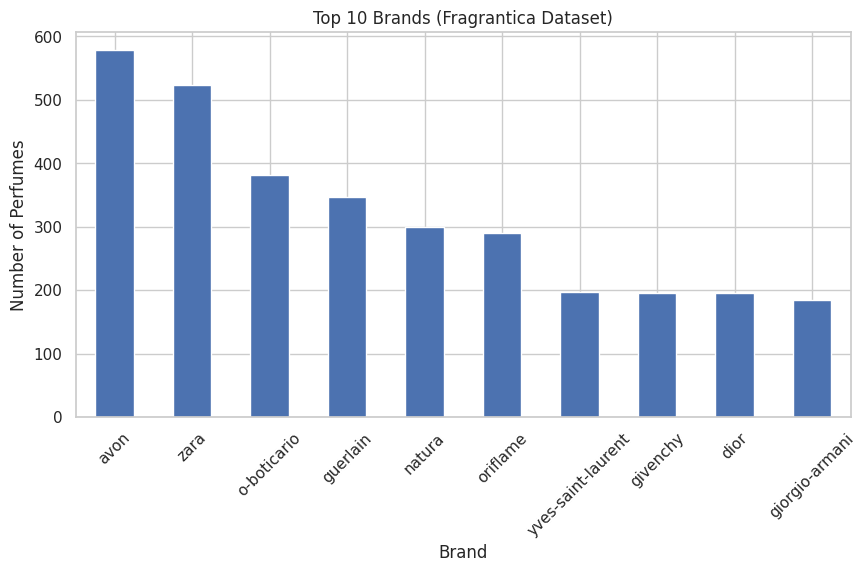

In [75]:
plt.figure(figsize=(10,5))
df_fragrance["Brand"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Brands (Fragrantica Dataset)")
plt.xlabel("Brand")
plt.ylabel("Number of Perfumes")
plt.xticks(rotation=45)
plt.show()

Most Common Top Notes

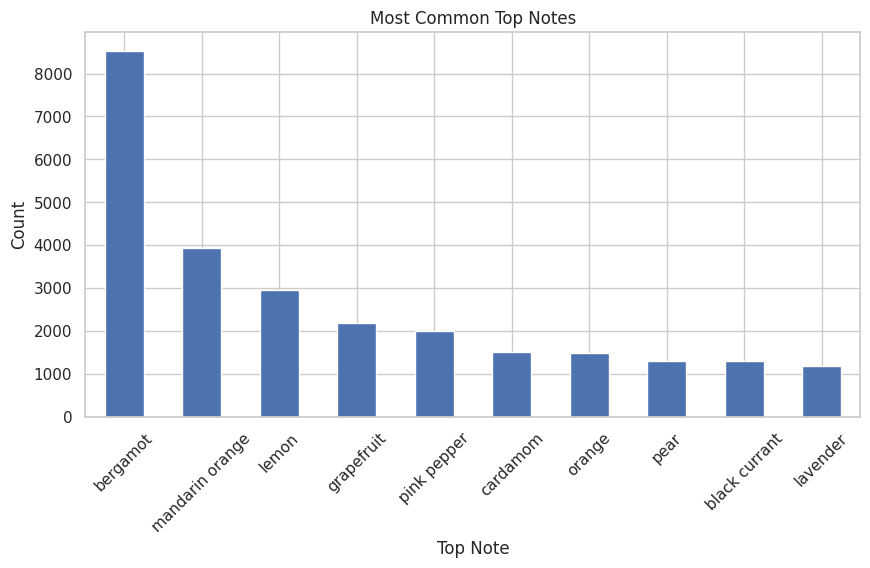

In [76]:
top_notes = df_fragrance["Top"].dropna().astype(str).str.split(",").explode().str.strip()
plt.figure(figsize=(10,5))
top_notes.value_counts().head(10).plot(kind="bar")
plt.title("Most Common Top Notes")
plt.xlabel("Top Note")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Most Common Middle Notes

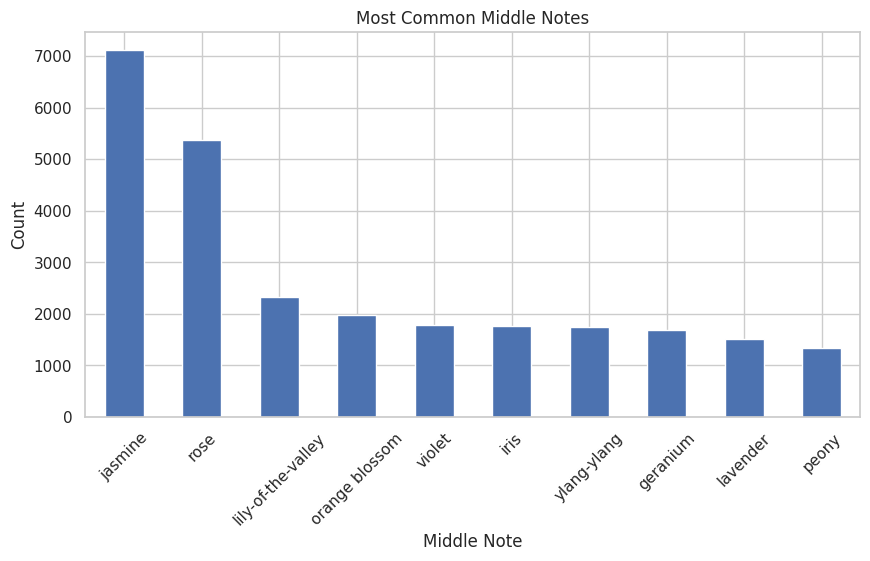

In [77]:
middle_notes = df_fragrance["Middle"].dropna().astype(str).str.split(",").explode().str.strip()
plt.figure(figsize=(10,5))
middle_notes.value_counts().head(10).plot(kind="bar")
plt.title("Most Common Middle Notes")
plt.xlabel("Middle Note")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Most Common Base Notes

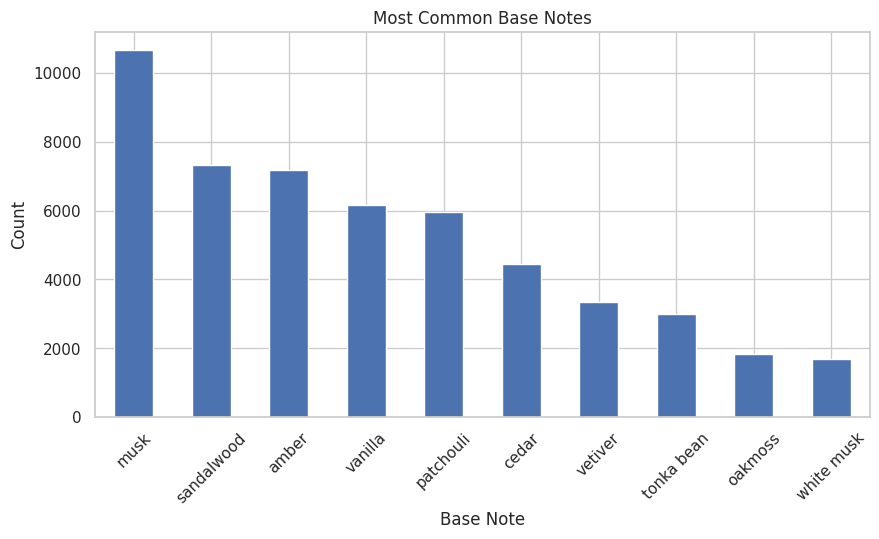

In [78]:
base_notes = df_fragrance["Base"].dropna().astype(str).str.split(",").explode().str.strip()
plt.figure(figsize=(10,5))
base_notes.value_counts().head(10).plot(kind="bar")
plt.title("Most Common Base Notes")
plt.xlabel("Base Note")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Gender Distribution

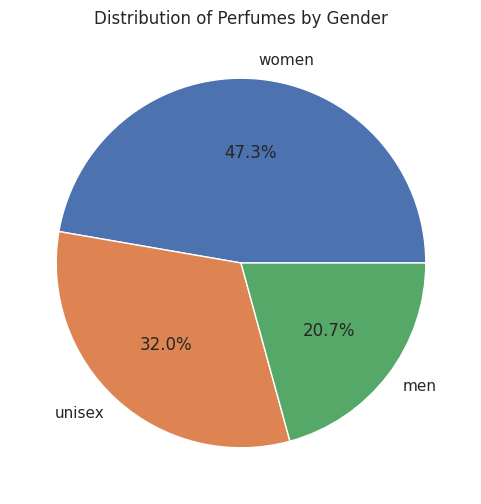

In [79]:
plt.figure(figsize=(6,6))
df_fragrance["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Perfumes by Gender")
plt.ylabel("")
plt.show()

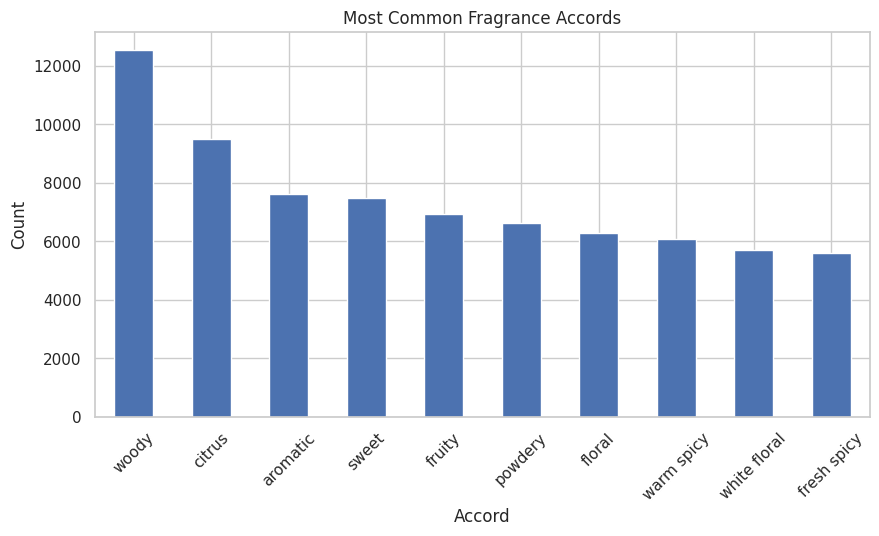

In [22]:
accords = pd.concat([
    df_fragrance["mainaccord1"],
    df_fragrance["mainaccord2"],
    df_fragrance["mainaccord3"],
    df_fragrance["mainaccord4"],
    df_fragrance["mainaccord5"]
])

plt.figure(figsize=(10,5))
accords.value_counts().head(10).plot(kind="bar")
plt.title("Most Common Fragrance Accords")
plt.xlabel("Accord")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Prcies from 2nd dataset

In [23]:
df_price["price_clean"] = (
    df_price["price"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)
df_price["price_clean"] = pd.to_numeric(df_price["price_clean"], errors="coerce")

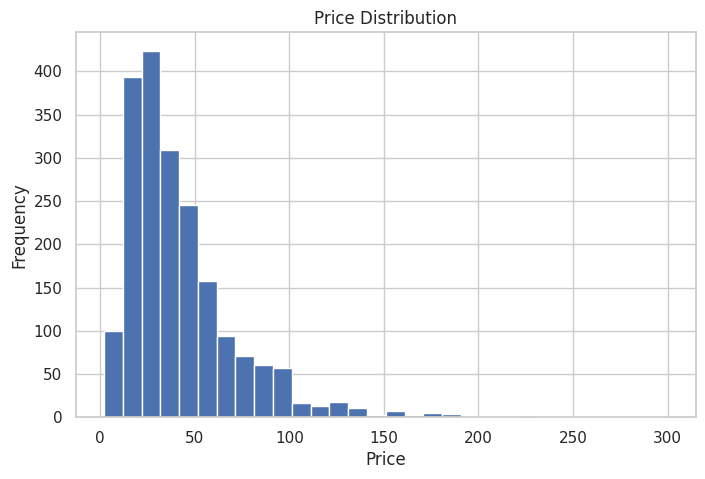

In [22]:
plt.figure(figsize=(8,5))
df_price["price_clean"].dropna().hist(bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Brand distribution in second dataset.

Some brands dominate the dataset, indicating uneven representation of products.

<Axes: xlabel='brand'>

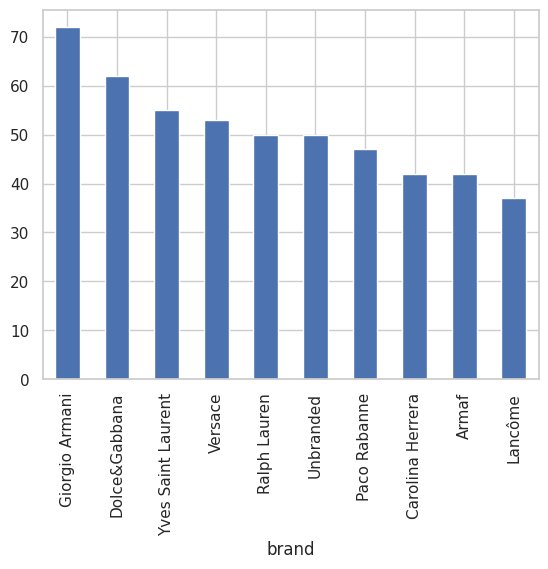

In [24]:
df_price["brand"].value_counts().head(10).plot(kind="bar")

Price by Type

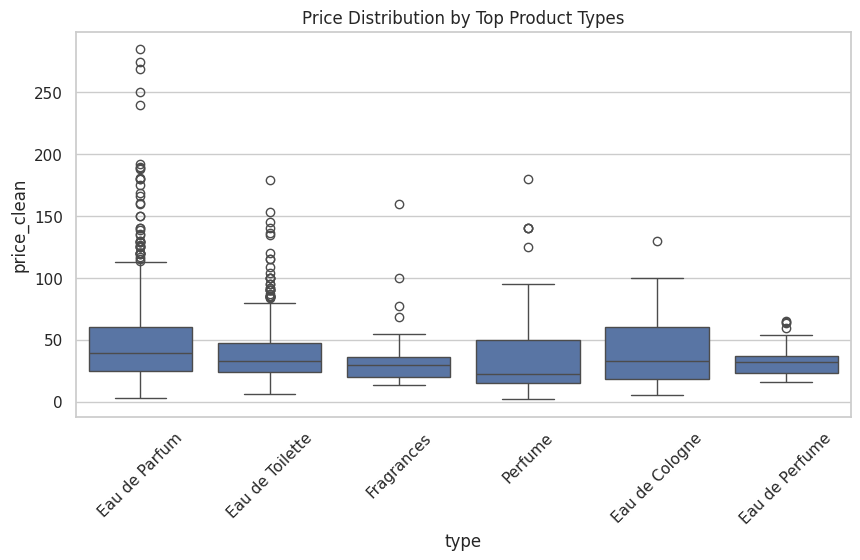

In [25]:
top_types = df_price["type"].value_counts().head(6).index

plt.figure(figsize=(10,5))
sns.boxplot(
    x="type",
    y="price_clean",
    data=df_price[df_price["type"].isin(top_types)]
)

plt.xticks(rotation=45)
plt.title("Price Distribution by Top Product Types")
plt.show()

Price distribution by brand

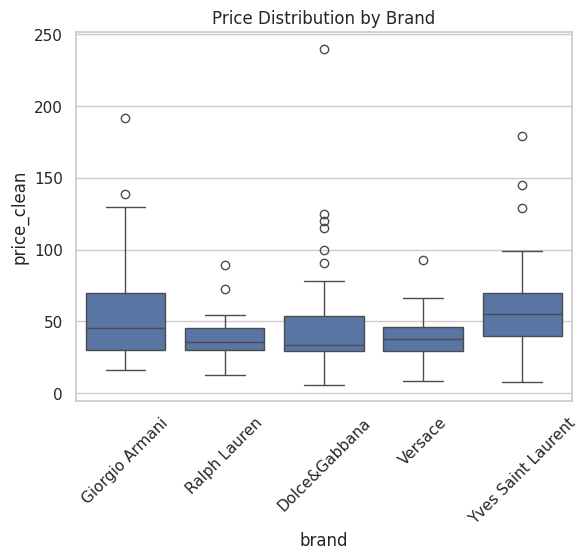

In [26]:
top_brands = df_price["brand"].value_counts().head(5).index

sns.boxplot(
    x="brand",
    y="price_clean",
    data=df_price[df_price["brand"].isin(top_brands)]
)
plt.xticks(rotation=45)
plt.title("Price Distribution by Brand")
plt.show()

# **Stage 2**

*Justification for the property that you would like the model to predict.*

I want to model similarity between perfumes based on their fragrance composition and to use this similarity for recommendation.

Since perfumes are described using top, middle and base notes, these features will be used as the input representation.

Unsupervised learning methods such as clustering and nearest neighbour search will be applied to group similar perfumes and recommend alternatives.

Question

Can perfume similarity be modeled using top, middle and base notes, and can those recommendations be filtered by price range?

# **Stage 3**

*Cleaning the data, linking datasets, preparing features.*



Creating working copies and clean price column

In [81]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer

fragrance = df_fragrance.copy()
price_data = df_price.copy()
price_data["price_clean"] = (
    price_data["price"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True))
price_data["price_clean"] = pd.to_numeric(price_data["price_clean"], errors="coerce")

Standardize text fields

In [82]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

fragrance["perfume_clean"] = fragrance["Perfume"].apply(clean_text)
fragrance["brand_clean"] = fragrance["Brand"].apply(clean_text)
price_data["title_clean"] = price_data["title"].apply(clean_text)
price_data["brand_clean"] = price_data["brand"].apply(clean_text)
price_data["type_clean"] = price_data["type"].apply(clean_text)

Clean note columns, combine notes into one feature

In [83]:
for col in ["Top", "Middle", "Base"]:
    fragrance[col] = fragrance[col].fillna("").astype(str).str.lower().str.strip()

fragrance["all_notes"] = (
    fragrance["Top"] + ", " +
    fragrance["Middle"] + ", " +
    fragrance["Base"])

fragrance["all_notes"] = fragrance["all_notes"].apply(clean_text)

Drop rows with no note information, Create link keys, First merge by brand

In [84]:
fragrance = fragrance[fragrance["all_notes"].str.strip() != ""].copy()

merged = pd.merge(
    fragrance,
    price_data,
    on="brand_clean",
    how="left",
    suffixes=("_frag", "_price"))

Keeping likely title matches

perfume name should appear inside title

In [85]:
merged["possible_match"] = merged.apply(
    lambda row: row["perfume_clean"] in row["title_clean"] if pd.notna(row["title_clean"]) else False,
    axis=1)
df_model = merged[merged["possible_match"] == True].copy()
df_model = df_model.reset_index(drop=True)

print("Fragrance dataset shape:", fragrance.shape)
print("Price dataset shape:", price_data.shape)
print("Merged dataset shape:", df_model.shape)
print("Filtered linked dataset shape:", df_model.shape)


Fragrance dataset shape: (24063, 21)
Price dataset shape: (2000, 14)
Merged dataset shape: (2701, 35)
Filtered linked dataset shape: (2701, 35)


To ensure recommendations only include actual perfumes (not deodorants, body sprays, etc.), I filter the merged dataset to keep only rows where the product type is one of the main perfume types: "parfum", "eau de parfum", "eau de toilette" or "eau de cologne" (case-insensitive, using the cleaned type column).

In [86]:
# Filter to keep only main perfume types
main_perfume_types = ["parfum", "eau de parfum", "eau de toilette", "eau de cologne"]
df_model = df_model[df_model["type_clean"].isin(main_perfume_types)].copy()

vectorization of notes

TF-IDF (Term Frequency-Inverse Document Frequency)

https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/

https://medium.com/@ashwinkumar577/countvectorizer-and-tfidfvectorizer-for-beginner-ac81afef30aa

In [87]:
vectorizer = TfidfVectorizer()
X_notes = vectorizer.fit_transform(fragrance["all_notes"])

print("TF-IDF matrix shape:", X_notes.shape)

TF-IDF matrix shape: (24063, 1254)


view cleaned data

In [88]:
display(fragrance[["Perfume", "Brand", "Top", "Middle", "Base", "all_notes"]].head())
display(price_data[["brand", "title", "type", "price", "price_clean"]].head())
display(df_model[["Perfume", "Brand", "title", "brand", "type", "price_clean"]].head())

,Perfume,Brand,Top,Middle,Base,all_notes
0,accento-overdose-pride-edition,xerjoff,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",fruity notes aldehydes green notes bulgarian r...
1,classique-pride-2024,jean-paul-gaultier,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",yuzu citruses orange blossom neroli musk blond...
2,classique-pride-2023,jean-paul-gaultier,"blood orange, yuzu","neroli, orange blossom","musk, white woods",blood orange yuzu neroli orange blossom musk w...
3,pride-edition-man,bruno-banani,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",guarana grapefruit red apple walnut lavender g...
4,le-male-pride-collector,jean-paul-gaultier,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",mint lavender cardamom artemisia bergamot cara...


,brand,title,type,price,price_clean
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,84.99
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,109.99
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,100.00
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,44.99
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,16.91


,Perfume,Brand,title,brand,type,price_clean
0,1-million,paco-rabanne,1 Million by Paco Rabanne 3.4 Fl oz / 100 ml P...,Paco Rabanne,PARFUM,68.99
1,1-million,paco-rabanne,1 Million Paco Rabanne Men 3.4 oz EDT Spray,Paco Rabanne,Eau de Toilette,49.99
2,1-million,paco-rabanne,1 Million Paco Rabanne Men 3.4 oz EDT Spray *F...,Paco Rabanne,Eau de Toilette,49.96
3,1-million,paco-rabanne,Paco Rabanne 1 Million Men's Fragrance EDT Col...,Paco Rabanne,Eau de Toilette,49.99
4,1-million,paco-rabanne,1 Million by Paco Rabanne 3.4 oz EDT Cologne f...,Paco Rabanne,Eau de Toilette,47.99


In this stage, the datasets were cleaned and prepared for modelling. The fragrance dataset was processed by combining the top, middle and base notes into a single text feature representing each perfume. This text was then transformed into a numerical representation using TF-IDF vectorization, allowing similarity between perfumes to be computed.

The pricing dataset was cleaned by converting price values into a consistent numeric format. Text fields in both datasets were standardised by converting them to lowercase, removing punctuation, and normalising spacing.

Two datasets were linked using both brand and perfume name. A brand-based merge was first applied, followed by filtering where the cleaned perfume name appeared within the product title. This approach reduces incorrect matches that could occur if only brand or title were used. Product type was also retained because items such as deodorants or body sprays may have different prices from perfumes.

# **Stage 4**
*Choose and train Estimator.*

In this stage, clustering is applied to the TF-IDF representation of perfume notes.

The goal is to group perfumes with similar fragrance compositions into clusters. Since the data does not contain predefined target labels for perfume categories, an unsupervised learning approach is appropriate.

KMeans was selected because it is a simple and widely used clustering algorithm that groups observations based on similarity in feature space. In this project, similarity is based on the combined top, middle, and base notes of each perfume.

Transform notes into TF-IDF vectors

In [124]:
X_notes = vectorizer.fit_transform(fragrance["all_notes"])
X_notes.shape

(24063, 1254)

Train KMeans clustering model

In [125]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
fragrance["cluster"] = kmeans.fit_predict(X_notes)
fragrance[["Perfume", "Brand", "cluster"]].head()

,Perfume,Brand,cluster
0,accento-overdose-pride-edition,xerjoff,1
1,classique-pride-2024,jean-paul-gaultier,5
2,classique-pride-2023,jean-paul-gaultier,5
3,pride-edition-man,bruno-banani,3
4,le-male-pride-collector,jean-paul-gaultier,3


The KMeans model was trained with 6 clusters. The `random_state` parameter was fixed to ensure reproducibility, meaning the same clustering result can be obtained each time notebook runs.

At this point, each perfume has been assigned a cluster label from 0 to 5. These labels are numerical and do not carry real-world meaning.

The next step is to examine the contents of each cluster and identify what fragrance profile each one represents.

Checking how many perfumes were assigned to each cluster

In [126]:
fragrance["cluster"].value_counts().sort_index()

,count
cluster,
0,1463
1,2584
2,2424
3,6006
4,3246
5,8340


Examining the number of perfumes in each cluster helps identify whether the clustering is balanced or if some clusters dominate. Large imbalances may indicate that some fragrance styles are overrepresented.

The clusters are not perfectly balanced, which is expected in real-world fragrance data because some scent families are more common than others. However, all clusters contain a meaningful number of perfumes, so clustering can still be considered useful in this case.



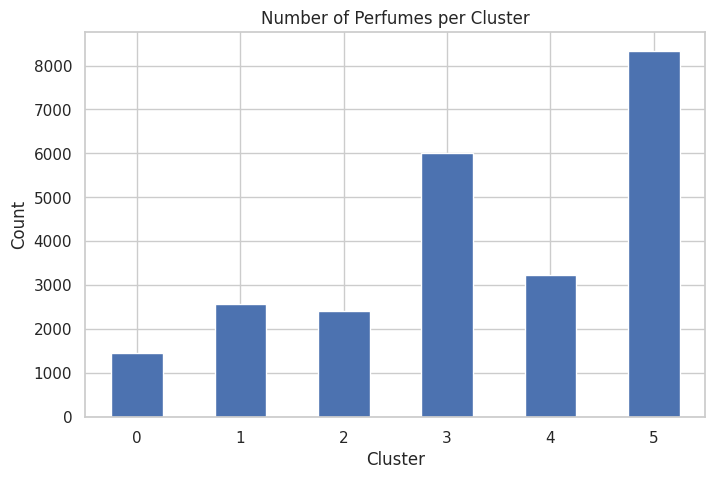

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
fragrance["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Perfumes per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

This graph shows how perfumes are distributed across the six clusters. Although the distribution is uneven, each cluster contains enough perfumes. This suggests that the selected number of clusters is reasonable for this dataset.

Showing the most common note terms inside each cluster

In [103]:
for i in range(6):
    print(f"\nCluster {i}")

    cluster_data = fragrance[fragrance["cluster"] == i]
    notes = cluster_data["all_notes"].str.split().explode()

    print(notes.value_counts().head(10))


Cluster 0
all_notes
oud           1600
agarwood      1425
rose           863
patchouli      708
musk           704
sandalwood     603
amber          602
saffron        545
vanilla        529
cedar          438
Name: count, dtype: int64

Cluster 1
all_notes
lily          2818
of            2600
the           2586
valley        2585
musk          1994
jasmine       1582
rose          1420
sandalwood    1297
orange        1295
bergamot      1182
Name: count, dtype: int64

Cluster 2
all_notes
pepper       2589
pink         2153
musk         1247
patchouli     967
rose          966
bergamot      881
orange        869
jasmine       859
amber         783
cedar         770
Name: count, dtype: int64

Cluster 3
all_notes
cedar         2780
bergamot      2685
musk          2377
patchouli     2310
vetiver       1985
amber         1932
lavender      1897
sandalwood    1851
lemon         1674
orange        1614
Name: count, dtype: int64

Cluster 4
all_notes
notes       4413
musk        1830
amber  

The output above helps interpret each cluster by showing its most common note terms. This is important because KMeans only returns numerical cluster labels. To understand what each cluster means, the dominant fragrance notes inside each cluster must be examined.

From this analysis, patterns can be identified. For example, a cluster dominated by oud, agarwood, saffron and amber can be interpreted as oriental, while a cluster dominated by jasmine, rose, lily of the valley and orange blossom can be interpreted as floral.

To further understand the structure of the data, PCA (Principal Component Analysis) was used to reduce the high-dimensional TF-IDF vectors into two dimensions.

The PCA plot shows that perfumes form visible groupings, indicating that similar fragrances are located close to each other in feature space. Some clusters are clearly separated, while others overlap slightly, which is expected due to shared ingredients across perfumes.

This visualisation supports the use of clustering, as the data exhibits structure rather than random distribution.

In [96]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_dense = X_notes.toarray()
pca = PCA(n_components=2, random_state=42)
X_pca2 = pca.fit_transform(X_dense)
print(X_pca2.shape)

(24063, 2)


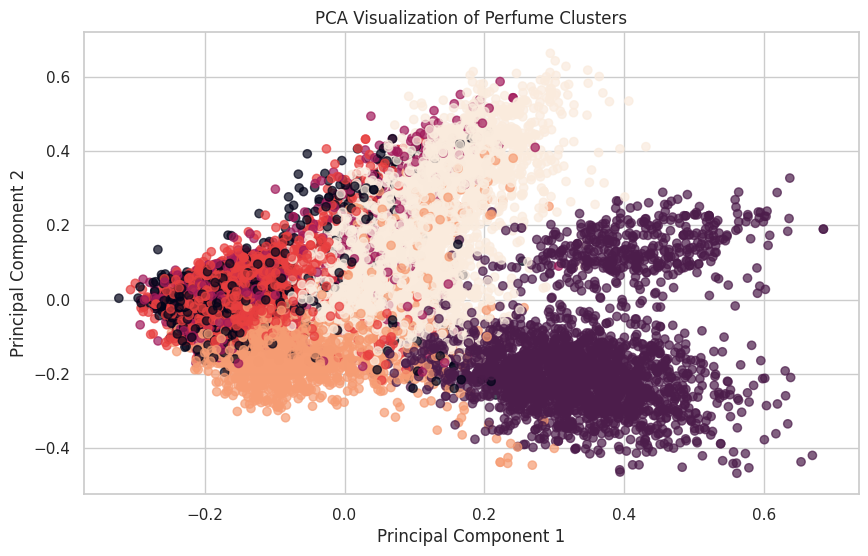

In [128]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=fragrance["cluster"], alpha=0.7)
plt.title("PCA Visualization of Perfume Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

PCA was used to project the data into two dimensions for visualization. The scatter plot shows how perfumes are distributed in the reduced feature space, with colours representing the cluster assigned by KMeans. This helps illustrate whether perfumes with similar note compositions form meaningful groups.

The PCA plot shows that perfumes form visible groups based on their fragrance notes. Although the groups are not perfectly separated, there is clear structure in the data. This suggests that perfumes with similar compositions are closer together, while different perfumes are further apart.

Therefore, clustering methods such as KMeans can be used to group perfumes with similar scent characteristics.


##Asigning Cluster names

Firstly, I extract the most important notes for each cluster using TF-IDF, which helps interpret and name the clusters meaningfully.

In [129]:
import numpy as np

def get_top_terms_per_cluster(X, labels, feature_names, top_n=8):
    cluster_top_terms = {}
    for cluster_num in sorted(np.unique(labels)):
        cluster_rows = X[labels == cluster_num]
        mean_tfidf = cluster_rows.mean(axis=0)
        mean_tfidf = np.asarray(mean_tfidf).ravel()
        top_indices = mean_tfidf.argsort()[::-1][:top_n]
        top_terms = [feature_names[i] for i in top_indices]
        cluster_top_terms[cluster_num] = top_terms

    return cluster_top_terms

In [130]:
feature_names = vectorizer.get_feature_names_out()
# Show top TF-IDF terms per cluster
cluster_top_terms = get_top_terms_per_cluster(
    X_notes,
    fragrance["cluster"].values,
    feature_names,
    top_n=8)
# Suggest cluster names from top terms
cluster_names_auto = {}
for cluster_num, terms in cluster_top_terms.items():
    cluster_names_auto[cluster_num] = " / ".join(terms[:3])
    print(f"Cluster {cluster_num} (suggested name: {cluster_names_auto[cluster_num]}): {', '.join(terms)}")

Cluster 0 (suggested name: oud / agarwood / saffron): oud, agarwood, saffron, rose, patchouli, amber, sandalwood, musk
Cluster 1 (suggested name: valley / the / of): valley, the, of, lily, musk, jasmine, rose, ylang
Cluster 2 (suggested name: pepper / pink / patchouli): pepper, pink, patchouli, musk, rose, orange, bergamot, cedar
Cluster 3 (suggested name: cedar / lavender / bergamot): cedar, lavender, bergamot, vetiver, patchouli, cardamom, lemon, amber
Cluster 4 (suggested name: notes / woody / woodsy): notes, woody, woodsy, musk, green, amber, floral, orange
Cluster 5 (suggested name: orange / jasmine / musk): orange, jasmine, musk, rose, vanilla, ylang, sandalwood, blossom


The top TF-IDF terms for each cluster reveal the dominant notes.

If clusters share many top terms, it may indicate overlapping styles or insufficient separation.

Unique top terms suggest well-differentiated clusters.

To make the model output easier to understand, the numerical cluster labels are converted into descriptive perfume categories based on the dominant notes found.

In [131]:
cluster_names = {
    0: "oud woody oriental",
    1: "white floral",
    2: "spicy fresh",
    3: "woody aromatic",
    4: "green woody",
    5: "sweet floral"}

fragrance["category"] = fragrance["cluster"].map(cluster_names)
fragrance[["Perfume", "Brand", "cluster", "category"]].head(10)

,Perfume,Brand,cluster,category
0,accento-overdose-pride-edition,xerjoff,1,white floral
1,classique-pride-2024,jean-paul-gaultier,5,sweet floral
2,classique-pride-2023,jean-paul-gaultier,5,sweet floral
3,pride-edition-man,bruno-banani,3,woody aromatic
4,le-male-pride-collector,jean-paul-gaultier,3,woody aromatic
5,le-male-pride-2023,jean-paul-gaultier,5,sweet floral
6,le-male-pride-2024,jean-paul-gaultier,4,green woody
7,polo-red-pride-edition,ralph-lauren,3,woody aromatic
8,ralph-pride-edition,ralph-lauren,5,sweet floral
9,waffle,we-pink,5,sweet floral


Descriptive fragrance categories instead of numbers make the model output easier to understand and more useful in the recommendation stage.

For example:
- Cluster 0 contains notes such as oud, agarwood, patchouli and saffron, so it was labelled **oud woody oriental**.
- Cluster 1 contains lily of the valley, jasmine, and rose, so it was labelled **white floral**.
- Cluster 5 contains vanilla, jasmine, orange, and blossom notes, so it was labelled **sweet floral**.

Distribution of the assigned perfume categories

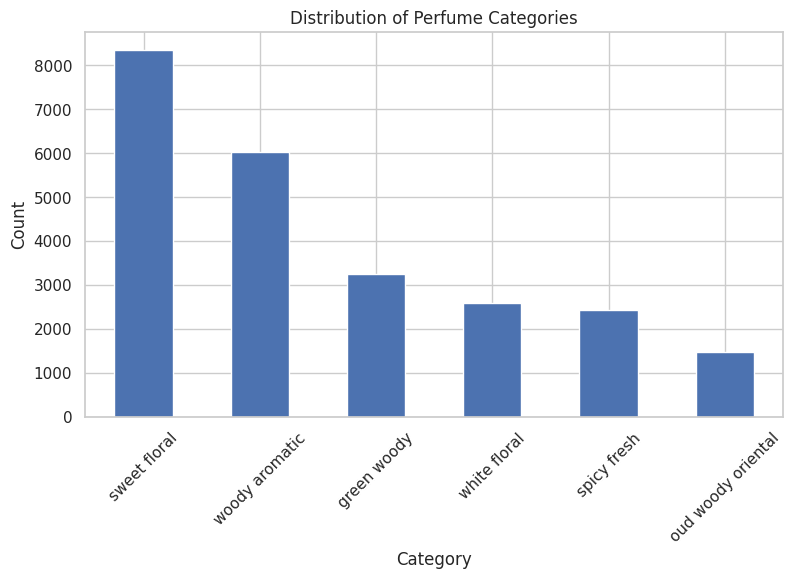

In [132]:
plt.figure(figsize=(9,5))
fragrance["category"].value_counts().plot(kind="bar")
plt.title("Distribution of Perfume Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

This graph shows the final distribution of perfumes across the interpreted fragrance categories. It provides a more meaningful view of the clustering results than the numerical labels alone.

Show sample perfumes from each category

In [133]:
for cat in fragrance["category"].unique():
    print(f"\nCategory: {cat}")
    display(fragrance[fragrance["category"] == cat][["Perfume", "Brand"]].head(5))


Category: white floral


,Perfume,Brand
0,accento-overdose-pride-edition,xerjoff
24,vetiver,franck-boclet
33,snow-palace,brocard
40,oshi,bi-es
50,flowers,franck-boclet



Category: sweet floral


,Perfume,Brand
1,classique-pride-2024,jean-paul-gaultier
2,classique-pride-2023,jean-paul-gaultier
5,le-male-pride-2023,jean-paul-gaultier
8,ralph-pride-edition,ralph-lauren
9,waffle,we-pink



Category: woody aromatic


...

,Perfume,Brand
6,le-male-pride-2024,jean-paul-gaultier
15,donald-trump,trump
16,school,rook-perfumes
26,quickie-and-coffee,filippo-sorcinelli
29,212-heroes-collector-edition,carolina-herrera



Category: oud woody oriental


,Perfume,Brand
14,erba-oud,sospiro-perfumes
23,oud-imperium,navitus-parfums
30,wild-carrot-oud,bohoboco
36,oud-luxuria,navitus-parfums
38,whispers-of-temptation,house-of-sillage



Category: spicy fresh


,Perfume,Brand
43,charming-snowdrop,pokrovka-trading-house
62,uviolet,faberlic
93,deep-dark-vanilla,ds-durga
95,elvie-white-magic,oriflame
143,lovely-kiss,salvador-dali


Show top accords per cluster

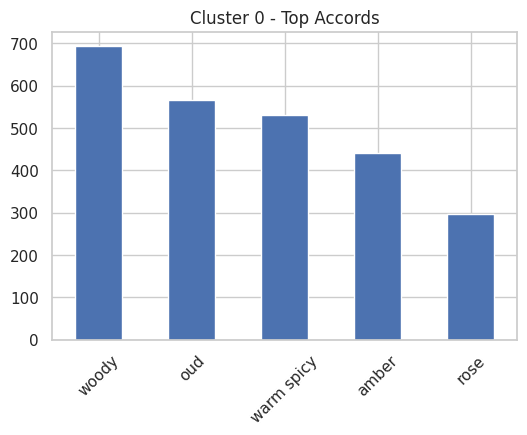

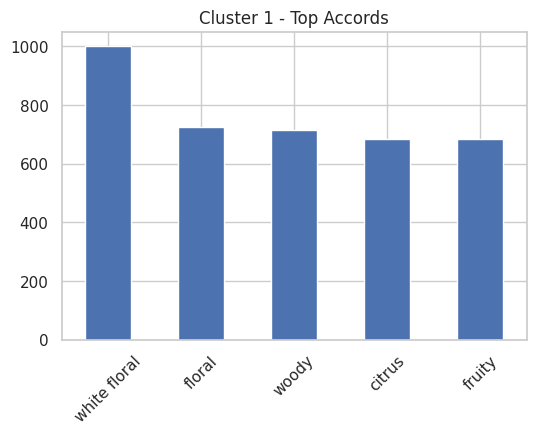

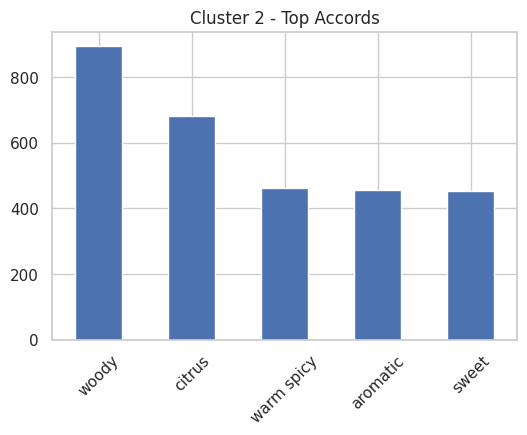

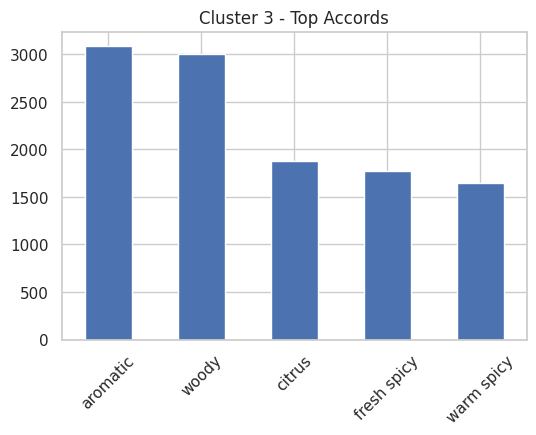

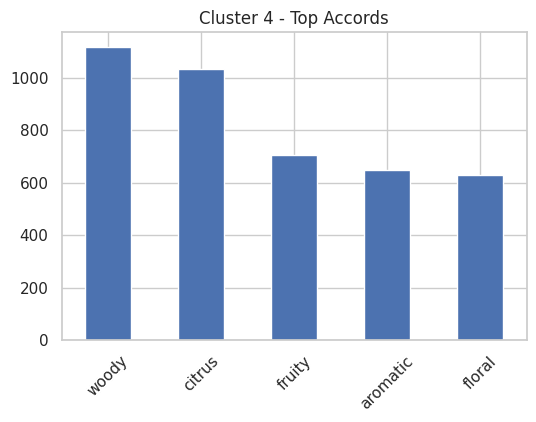

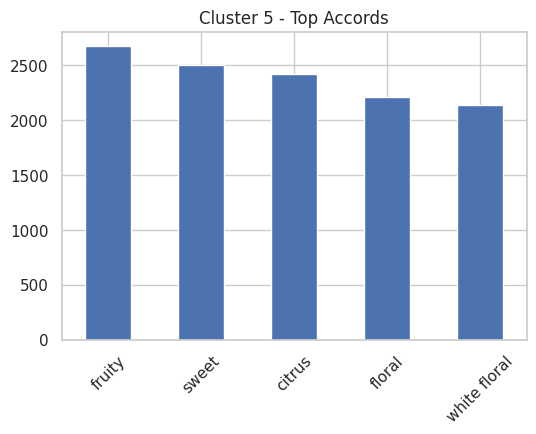

In [135]:
for i in range(6):
    cluster_data = fragrance[fragrance["cluster"] == i]
    accords = pd.concat([
        cluster_data["mainaccord1"],
        cluster_data["mainaccord2"],
        cluster_data["mainaccord3"]])
    plt.figure(figsize=(6,4))
    accords.value_counts().head(5).plot(kind="bar")
    plt.title(f"Cluster {i} - Top Accords")
    plt.xticks(rotation=45)
    plt.show()



These accord graphs provide an additional way to interpret each cluster. While the note-based analysis shows the detailed ingredients, accord-based graphs summarize the overall fragrance style of each cluster. This confirms that clusters correspond to recognizable perfume families such as woody, floral, spicy, fresh and sweet.

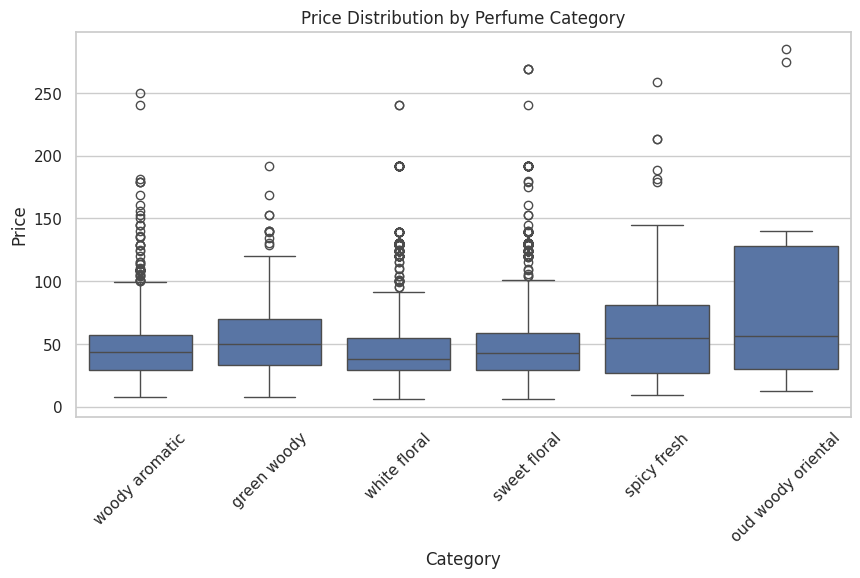

In [137]:
df_model = pd.merge(
    df_model,
    fragrance[["Perfume", "Brand", "category"]].drop_duplicates(),
    on=["Perfume", "Brand"],
    how="left"
)

plt.figure(figsize=(10,5))
sns.boxplot(x="category", y="price_clean", data=df_model)
plt.title("Price Distribution by Perfume Category")
plt.xlabel("Category")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

Analysing price distribution within each cluster reveals whether certain fragrance styles are associated with higher or lower price points. Outliers or wide spreads may indicate luxury or budget segments within a cluster.

This does not yet evaluate recommendation quality, but it provides useful descriptive insight into how pricing varies across fragrance families.

At this stage, the clustering model has been trained, visualised and interpreted.

The perfumes have been grouped into meaningful fragrance categories based on their note compositions and the cluster structure has been examined through distribution plots, PCA visualisation, note frequencies, accord graphs and price patterns.

# **Stage 5**
*Evaluate your model and revisit 4...repeat..*

Evaluation of clustering quality and testing of recommendation behaviour

The clustering results were evaluated using the silhouette score, which measures how well-separated the clusters are. Different numbers of clusters were tested to determine the most suitable value of k.

In [107]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_notes, fragrance["cluster"])
print("Silhouette score:", score)

Silhouette score: 0.025145621714669063


In [108]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_notes)
    score = silhouette_score(X_notes, labels)
    scores.append((k, score))
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.0110
k=3, silhouette=0.0168
k=4, silhouette=0.0227
k=5, silhouette=0.0218
k=6, silhouette=0.0251
k=7, silhouette=0.0304
k=8, silhouette=0.0304
k=9, silhouette=0.0321
k=10, silhouette=0.0308


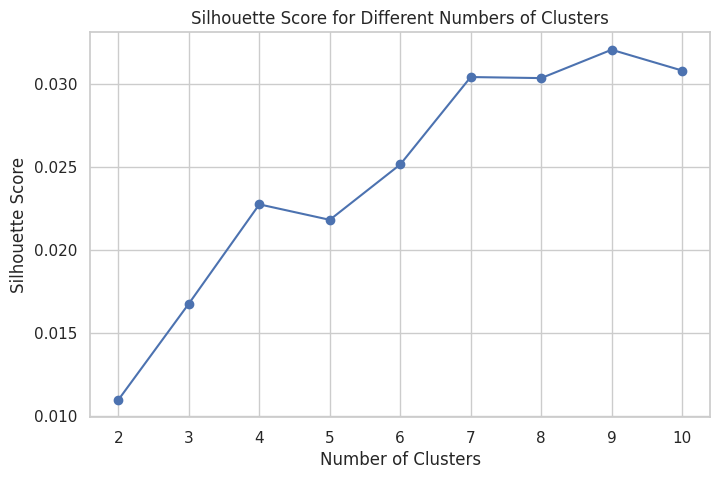

In [109]:
ks = [x[0] for x in scores]
vals = [x[1] for x in scores]

plt.figure(figsize=(8, 5))
plt.plot(ks, vals, marker="o")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

The silhouette score quantifies how well-separated the clusters are. A higher score indicates better-defined clusters. If the score is low, it may suggest that the clusters overlap or that the chosen number of clusters is not optimal.

# **Stage 6**
***Present results and Conclusions***



examples of recommended parfumes, clusters, price filtering,conclusions

##Bibliography

GeeksforGeeks (2025) Understanding TF-IDF (Term Frequency-Inverse Document Frequency). Available at: https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/
 (Accessed: 10 April 2026).

Scikit-learn (2026) TfidfVectorizer — scikit-learn documentation. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
 (Accessed: 10 April 2026).

Kumar, A. (2024) CountVectorizer and TfidfVectorizer for Beginner. Available at: https://medium.com/@ashwinkumar577/countvectorizer-and-tfidfvectorizer-for-beginner-ac81afef30aa
 (Accessed: 10 April 2026).

 Gültekin, H. (2023) What is Silhouette Score? Available at: https://medium.com/@hazallgultekin/what-is-silhouette-score-f428fb39bf9a
 (Accessed: 20 April 2026).

Abdulazeez, F. (2024) Understanding Silhouette Score in Clustering. Available at: https://farshadabdulazeez.medium.com/understanding-silhouette-score-in-clustering-8aedc06ce9c4
 (Accessed: 20 April 2026).